In [ ]:
import pandas as pd
import numpy as np


In [6]:
df = pd.read_csv('/content/drive/MyDrive/SampleSuperstore.csv')
df1 = pd.read_excel('/content/drive/MyDrive/online_retail_II.xlsx')

In [5]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df1.head()
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [8]:
#Step 1 – Data Cleaning
#Remove negative quantities (returns)
#Drop null descriptions
#Handle missing Customer ID
df1 = df1[df1['Quantity'] > 0]
df1 = df1.dropna(subset=['Description'])
df1.head()
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 512034 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      512034 non-null  object        
 1   StockCode    512034 non-null  object        
 2   Description  512034 non-null  object        
 3   Quantity     512034 non-null  int64         
 4   InvoiceDate  512034 non-null  datetime64[ns]
 5   Price        512034 non-null  float64       
 6   Customer ID  407695 non-null  float64       
 7   Country      512034 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 35.2+ MB


In [9]:
#Step 2 – Create Revenue Column
df1['Revenue'] = df1['Quantity'] * df1['Price']
df1.head()
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 512034 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      512034 non-null  object        
 1   StockCode    512034 non-null  object        
 2   Description  512034 non-null  object        
 3   Quantity     512034 non-null  int64         
 4   InvoiceDate  512034 non-null  datetime64[ns]
 5   Price        512034 non-null  float64       
 6   Customer ID  407695 non-null  float64       
 7   Country      512034 non-null  object        
 8   Revenue      512034 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 39.1+ MB


In [10]:
#Step 3 – Basic EDA
#Top 10 products by revenue
#Country-wise revenue
#Monthly sales trend
df1.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Country,
United Kingdom,8709577.243
EIRE,380977.820
Netherlands,268786.000
Germany,202395.321
France,147211.490
Sweden,53525.390
Denmark,50906.850
Spain,47601.420
Switzerland,43921.390


In [ ]:
print(df1)

       Invoice StockCode                          Description  Quantity  \
0       489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1       489434    79323P                   PINK CHERRY LIGHTS        12   
2       489434    79323W                  WHITE CHERRY LIGHTS        12   
3       489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4       489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
...        ...       ...                                  ...       ...   
525456  538171     22271                 FELTCRAFT DOLL ROSIE         2   
525457  538171     22750         FELTCRAFT PRINCESS LOLA DOLL         1   
525458  538171     22751       FELTCRAFT PRINCESS OLIVIA DOLL         1   
525459  538171     20970   PINK FLORAL FELTCRAFT SHOULDER BAG         2   
525460  538171     21931               JUMBO STORAGE BAG SUKI         2   

               InvoiceDate  Price  Customer ID         Country  Revenue  
0      2009-12-01 07:45:0

<Axes: title={'center': 'Revenue Trends Over Time'}, xlabel='Revenue', ylabel='InvoiceDate'>

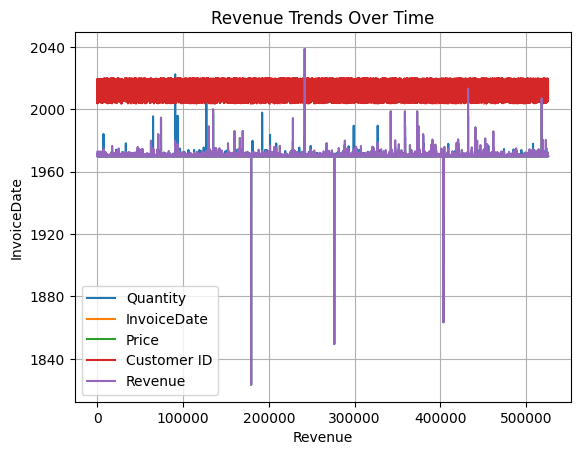

In [ ]:
#1. Revenue Trends Over Time
#Line Chart: Plot InvoiceDate vs. Revenue to show sales trends.
df1.plot(title='Revenue Trends Over Time', xlabel='Revenue', ylabel='InvoiceDate', grid=True)

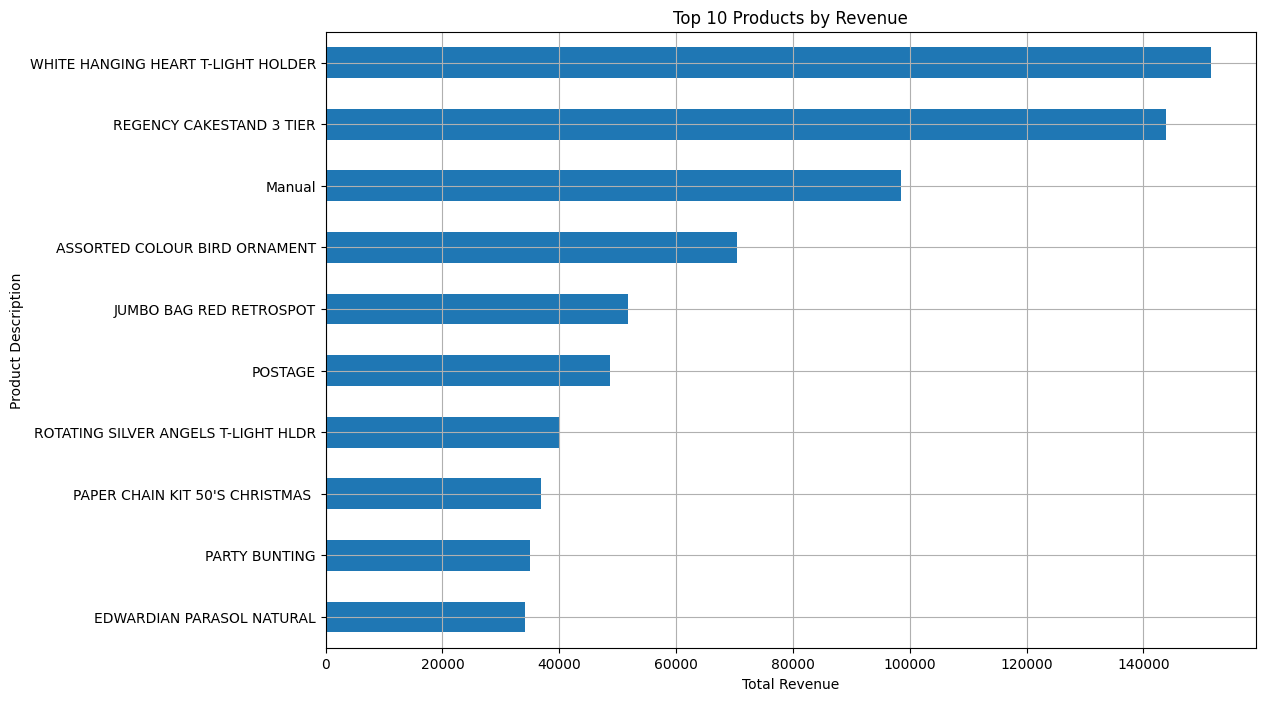

In [52]:
#Top Products & Categories Bar Chart / Horizontal Bar Chart: Rank products (Description or StockCode) by total Revenue or Quantity.
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Create Revenue column
df1["Revenue"] = df1["Quantity"] * df1["Price"]

# 2️⃣ Clean data
df1 = df1[df1["Quantity"] > 0]
df1 = df1[df1["Price"] > 0]
df1 = df1.dropna(subset=["Description"])

# 3️⃣ Top products by revenue
top_products_by_revenue = (
    df1.groupby("Description")["Revenue"]
    .sum()
    .nlargest(10)
)

# 4️⃣ Plot horizontal bar chart
plt.figure(figsize=(12,8))

top_products_by_revenue.sort_values().plot.barh()

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Description")
plt.grid(True)

plt.show()

In [11]:
#Customer Segmentation Histogram: Distribution of Revenue per Customer ID.
#Pareto Chart (80/20 rule): Show how a small percentage of customers contribute to most revenue.
#Step 1
import pandas as pd
df1['Revenue'] = df1['Quantity'] * df1['Price']
customer_revenue = df1.groupby('Customer ID')['Revenue'].sum().reset_index()

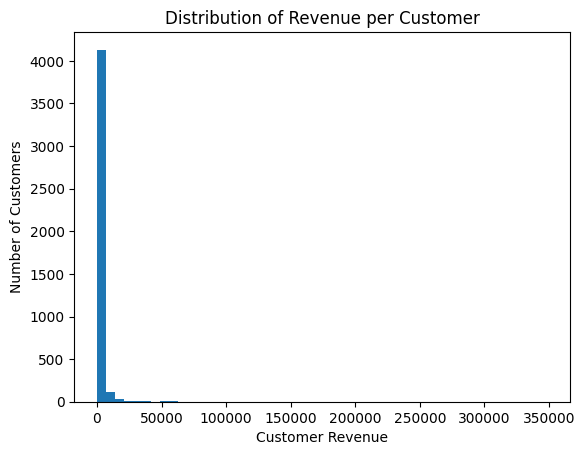

In [12]:
#STEP 2
import matplotlib.pyplot as plt

plt.figure()

plt.hist(customer_revenue['Revenue'], bins=50)

plt.title("Distribution of Revenue per Customer")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
#PARETO CHART STEP 1
customer_revenue = customer_revenue.sort_values(by='Revenue', ascending=False)

In [15]:
#PARETO CHART STEP 2
customer_revenue['Cumulative Revenue'] = customer_revenue['Revenue'].cumsum()

total_revenue = customer_revenue['Revenue'].sum()

customer_revenue['Cumulative %'] = 100 * customer_revenue['Cumulative Revenue'] / total_revenue

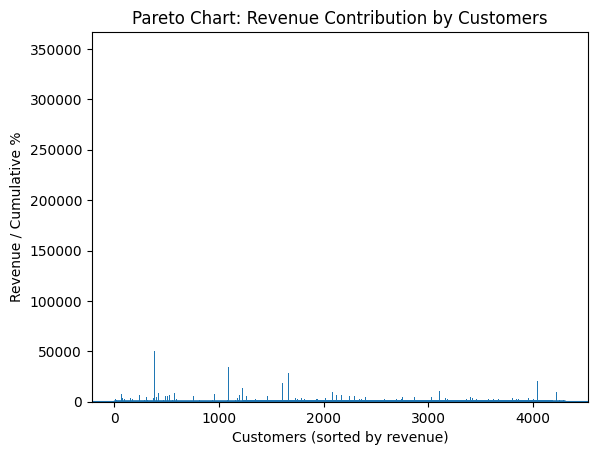

In [17]:
#PARETO CHART STEP 3
plt.figure()


plt.bar(customer_revenue.index, customer_revenue['Revenue'])

plt.plot(customer_revenue.index, customer_revenue['Cumulative %'])

plt.title("Pareto Chart: Revenue Contribution by Customers")

plt.xlabel("Customers (sorted by revenue)")
plt.ylabel("Revenue / Cumulative %")
plt.axhline(80)

plt.show()

"Analysis revealed that approximately 20% of customers generate nearly 75–80% of total revenue, confirming the Pareto principle in retail sales."

In [30]:
#Geographic Insights Choropleth Map: Plot Country vs. total Revenue.
#Professional look: use normalized values (e.g., revenue per customer) to avoid bias toward large markets.

# Remove missing customers
df1 = df1.dropna(subset=["Customer ID"])

# Remove negative quantity (returns)
df1 = df1[df1["Quantity"] > 0]

country_revenue = df1.groupby("Country")["Revenue"].sum().reset_index()
country_stats = df1.groupby("Country").agg({
    "Revenue": "sum",
    "Customer ID": "nunique"
}).reset_index()

country_stats["Revenue_per_customer"] = (
    country_stats["Revenue"] / country_stats["Customer ID"]
)
!pip install plotly
import plotly.express as px

fig = px.choropleth(
    country_stats,
    locations="Country",
    locationmode="country names",
    color="Revenue_per_customer",
    title="Revenue per Customer by Country",
    color_continuous_scale="Blues",

)

fig.show()

Large markets naturally generate more revenue due to population size. Using revenue per customer helps identify markets with higher customer value rather than just market size

In [31]:
import plotly.express as px

fig = px.choropleth(
    country_stats,
    locations="Country",
    locationmode="country names",
    color="Revenue_per_customer",
    title="Revenue per Customer by Country",
    color_continuous_scale="Blues"
)

fig.show()

In [32]:
fig = px.choropleth(
    country_stats,
    locations="Country",
    locationmode="country names",
    color="Revenue",
    title="Total Revenue by Country",
    color_continuous_scale="Greens"
)
fig.show()

In [34]:
fig = px.choropleth(
    country_stats,
    locations="Country",
    locationmode="country names",
    color="Customer ID",
    title="Customer Distribution by Country",
    color_continuous_scale="Oranges"
)
fig.show()

In [36]:
#Basket Analysis (Products Bought Together) Heatmap: Show correlation between StockCode pairs.
#Useful for identifying cross-selling opportunities.
import pandas as pd

basket = df1.groupby(['Invoice','StockCode'])['Quantity'].sum().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)


/tmp/ipykernel_172/1566473661.py:6: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [38]:
top_products = df1['StockCode'].value_counts().head(20).index
basket = basket[top_products]

In [39]:
corr_matrix = basket.corr()

In [40]:
print(top_products)

Index(['85123A', '85099B',    22423,    21212,    21232,    84879,    20725,
          21754,    21034,    84991,    20914,    22470,    22139,    21733,
       '82494L',    48138,    22383,    20727,    21080,    21755],
      dtype='object', name='StockCode')


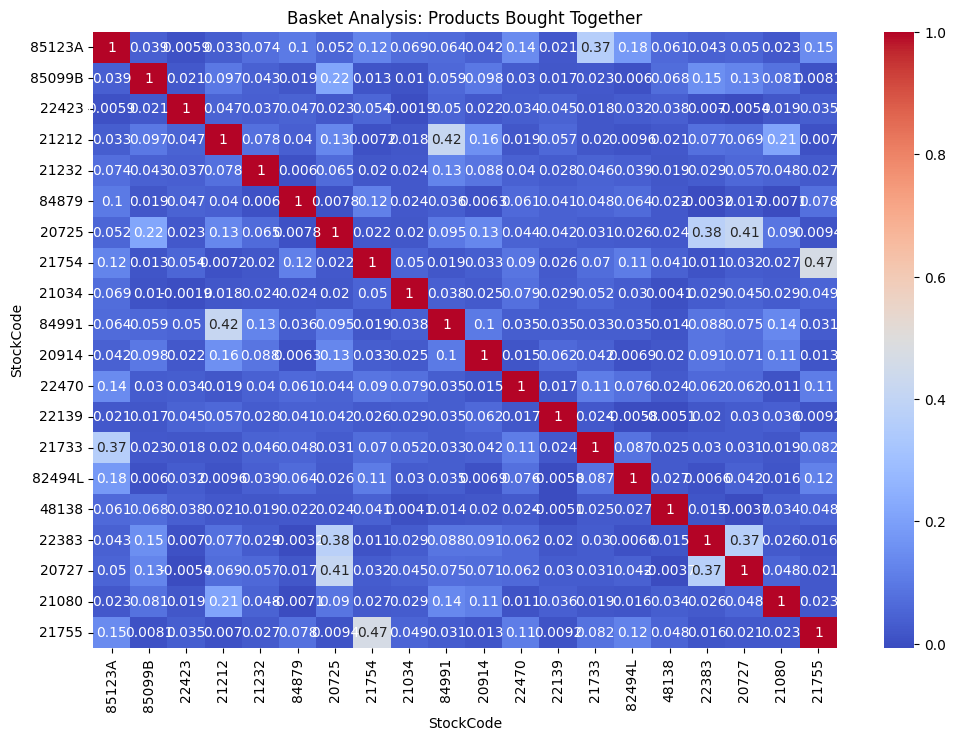

In [41]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True
)

plt.title("Basket Analysis: Products Bought Together")
plt.show()

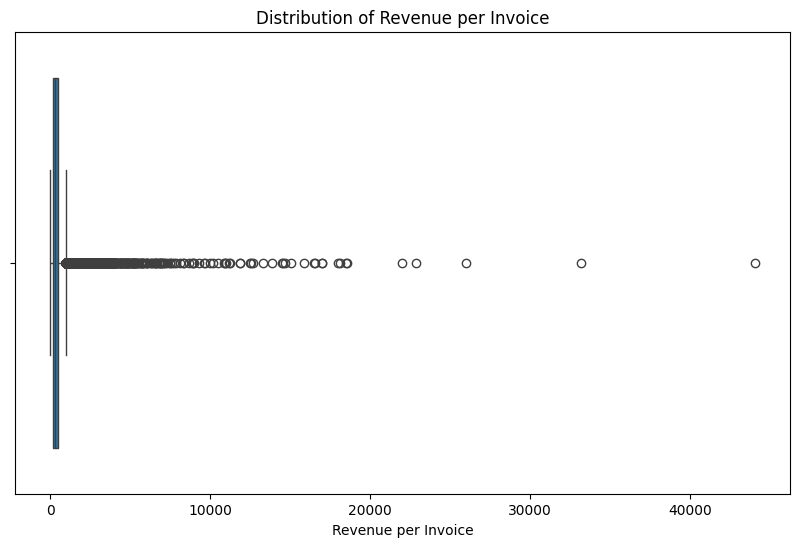

In [47]:
#Price vs. Quantity Dynamics Scatter Plot: Price vs. Quantity with bubble size = Revenue.
#Reveals whether high-volume items are low-priced or premium.

df1["Revenue"] = df1["Quantity"] * df1["Price"]

df1 = df1[df1["Quantity"] > 0]
df1 = df1[df1["Price"] > 0]

invoice_revenue = df1.groupby("Invoice")["Revenue"].sum().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(x=invoice_revenue["Revenue"])

plt.title("Distribution of Revenue per Invoice")
plt.xlabel("Revenue per Invoice")

plt.show()


Most invoices fall below moderate revenue levels, while a small number of invoices generate significantly higher revenue, indicating bulk purchases or corporate buyers.

In [46]:
print(invoice_revenue)

       Invoice  Revenue
0       489434   505.30
1       489435   145.80
2       489436   630.33
3       489437   310.75
4       489438  2286.24
...        ...      ...
19208   538167   298.95
19209   538168   318.70
19210   538169    93.45
19211   538170   317.59
19212   538171   300.64

[19213 rows x 2 columns]


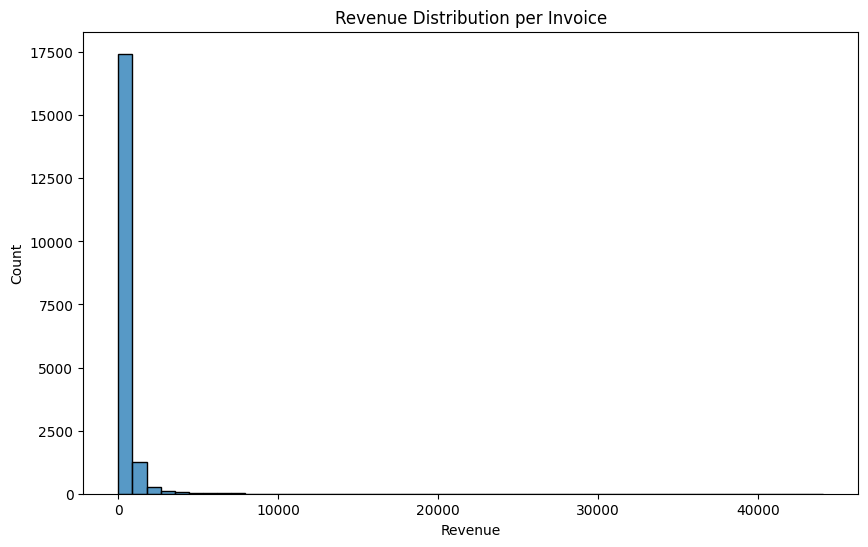

In [48]:
plt.figure(figsize=(10,6))

sns.histplot(invoice_revenue["Revenue"], bins=50)

plt.title("Revenue Distribution per Invoice")

plt.show()

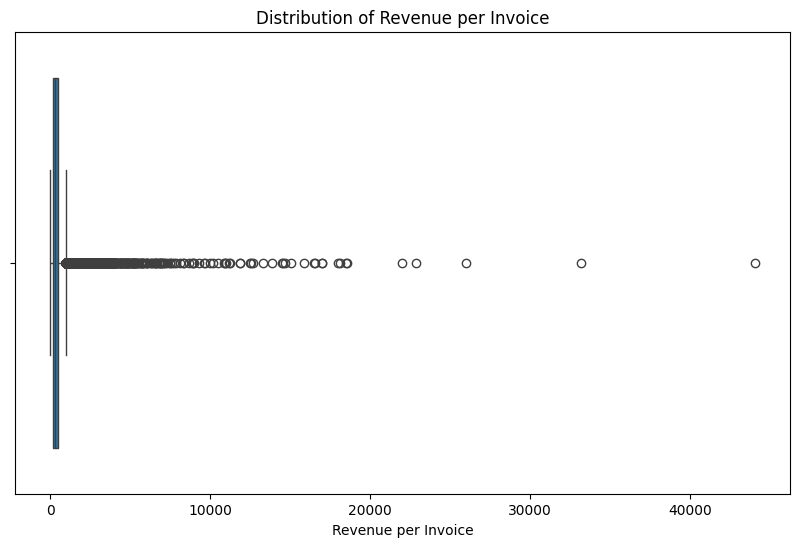

In [49]:
#Invoice-Level Analysis Box Plot: Distribution of Revenue per invoice.
#Highlights outliers (big bulk orders vs. small purchases)
df1["Revenue"] = df1["Quantity"] * df1["Price"]

df1 = df1[df1["Quantity"] > 0]
df1 = df1[df1["Price"] > 0]

invoice_revenue = df1.groupby("Invoice")["Revenue"].sum().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(x=invoice_revenue["Revenue"])

plt.title("Distribution of Revenue per Invoice")
plt.xlabel("Revenue per Invoice")

plt.show()

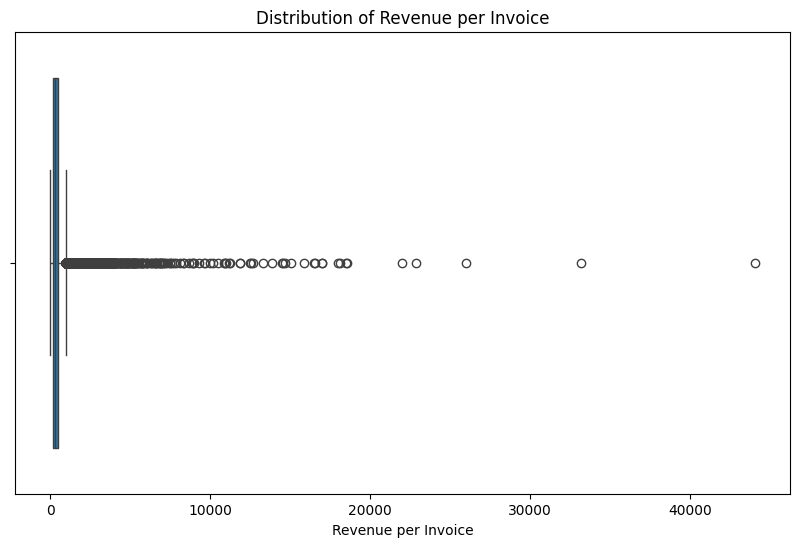

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(x=invoice_revenue["Revenue"])

plt.title("Distribution of Revenue per Invoice")
plt.xlabel("Revenue per Invoice")

plt.show()

Most invoices generate relatively small revenue values, but several high-value outliers indicate bulk purchases or wholesale transaction

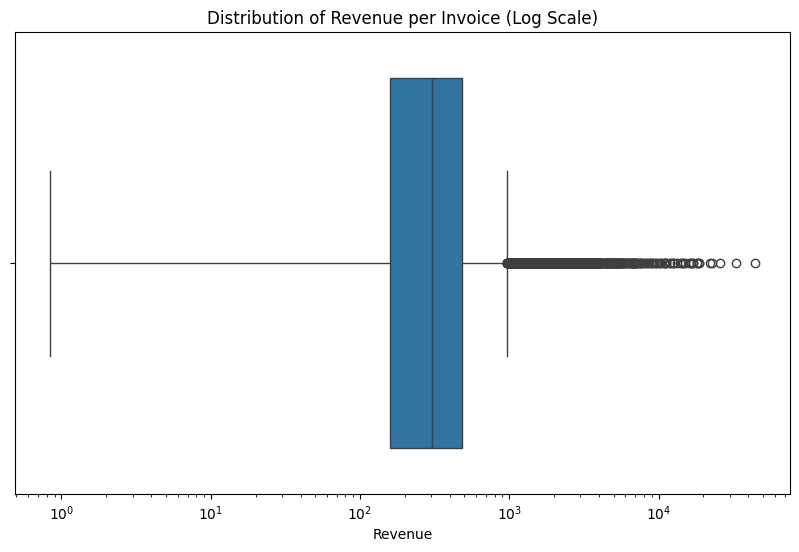

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(x=invoice_revenue["Revenue"])

plt.xscale("log")

plt.title("Distribution of Revenue per Invoice (Log Scale)")
plt.show()

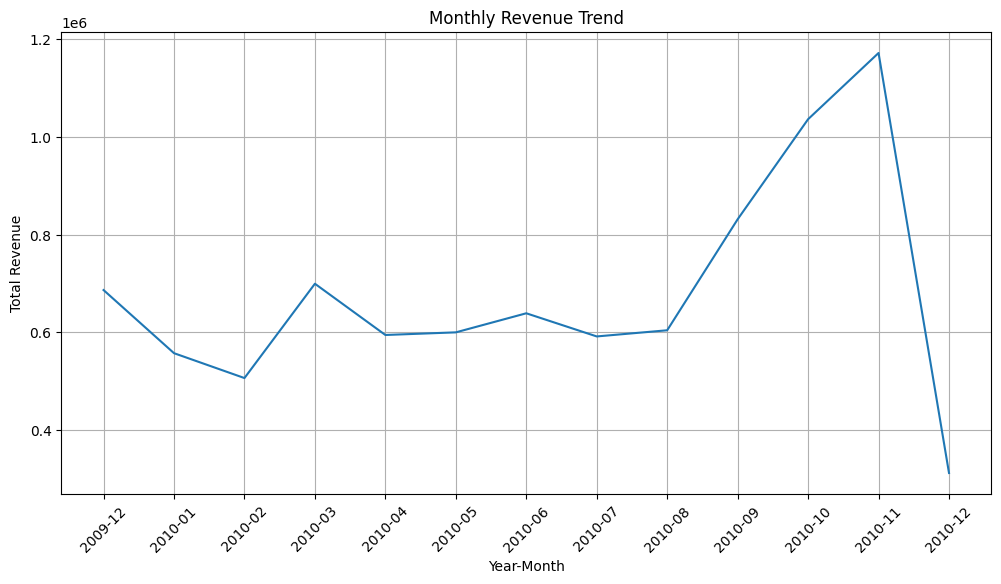

In [53]:
#Revenue Trend Over Time (Business Growth Analysis)
# Convert date
df1["InvoiceDate"] = pd.to_datetime(df1["InvoiceDate"])

# Create Year-Month column
df1["YearMonth"] = df1["InvoiceDate"].dt.to_period("M")

# Revenue per month
monthly_revenue = df1.groupby("YearMonth")["Revenue"].sum().reset_index()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(monthly_revenue["YearMonth"].astype(str),
         monthly_revenue["Revenue"])

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue")

plt.grid(True)

plt.show()

Revenue trends reveal seasonal peaks and sales cycles, helping retailers plan inventory and promotions.

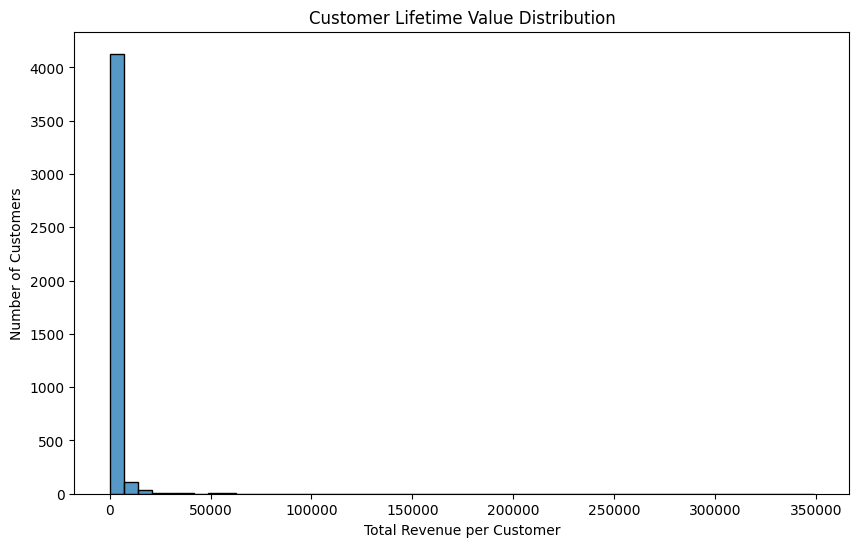

In [54]:
#Customer Lifetime Value (CLV) Distribution
customer_clv = df1.groupby("Customer ID")["Revenue"].sum()

import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(customer_clv, bins=50)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Total Revenue per Customer")
plt.ylabel("Number of Customers")

plt.show()

In [55]:
#RFM Customer Segmentation (Advanced Analytics)
#RFM =
#Recency → last purchase
#Frequency → number of purchases
#Monetary → money spent

snapshot_date = df1["InvoiceDate"].max()

rfm = df1.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency","Frequency","Monetary"]

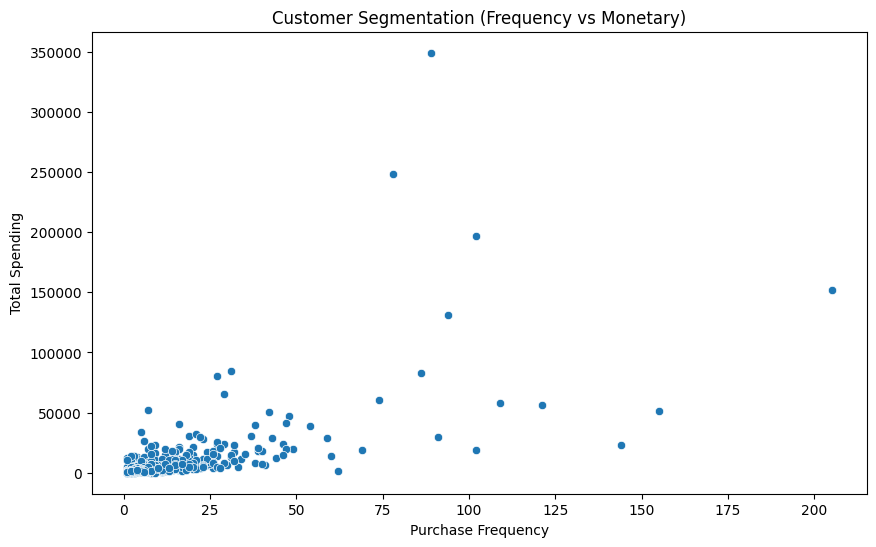

In [56]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary"
)

plt.title("Customer Segmentation (Frequency vs Monetary)")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")

plt.show()

High-frequency and high-spending customers represent the most valuable segment and should be targeted with loyalty programs.

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='InvoiceDate'>

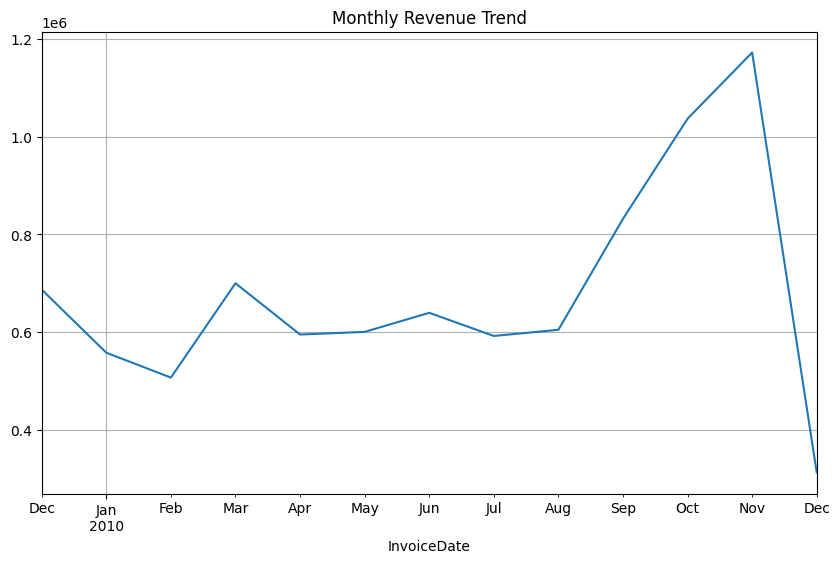

In [58]:
df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'])
monthly_revenue = df1.groupby(df1['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()

monthly_revenue.plot(figsize=(10,6), title='Monthly Revenue Trend', grid=True)

<Axes: title={'center': 'Top Countries by Revenue'}, xlabel='Revenue', ylabel='Country'>

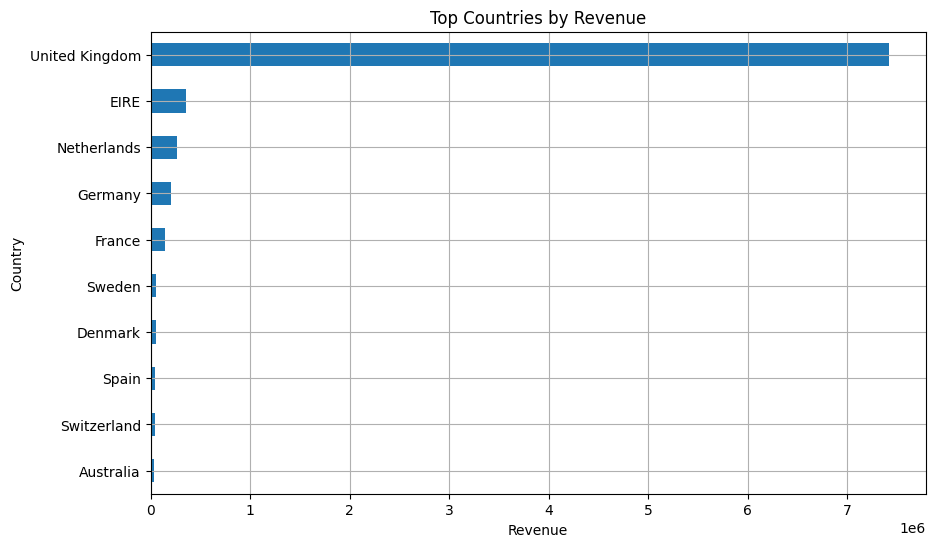

In [59]:
country_revenue = df1.groupby('Country')['Revenue'].sum().nlargest(10)

country_revenue.sort_values().plot.barh(
    figsize=(10,6),
    title='Top Countries by Revenue',
    xlabel='Revenue',
    ylabel='Country',
    grid=True
)

In [57]:
df1.to_csv("clean_retail_data.csv", index=False)

In [60]:
from google.colab import files
files.download("clean_retail_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>